# Results

In [6]:
SAVE_IN_ENGLISH = False

In [7]:
import os
import json
import sys

import pandas as pd
import numpy as np

from openqaoa.algorithms import QAOAResult
import matplotlib.pyplot as plt
from matplotlib import rcParams
#Parametros para graficas
#plt.style.use('dark_background')
rcParams.update( {'xtick.labelsize': 15, 'ytick.labelsize': 15, 'font.size': 18} )

from scipy.stats import norm,stats
from scipy.ndimage import zoom
    
sys.path.append(os.path.abspath(os.path.join('../../../..', 'functions')))
from JRPClassic import JRPClassic
from utils import *

### Uploading the experiment files

The experiment has been done for circuit configurations of $p=4$ and $p=5$. Each result file name represents which particular instance was used for reusing its parameters. That is, the name of a result file is formed by:

* the JRP Init. configuration used.
* the circuit configuration used.
* which of the 5 instances was used.

For example, if the file is named 'EvaluationQAOASolver_conf_jrpInitConf6_circuitConf1_instance0', that means that:

* 'circuitConf1' configuration was used for the reusing of the parameters, which corresponds to a circuit configuration with $p=4$.
* the instance 0 of 'jrpInitConf6' configuration was used for the reusing of the parameters, which corresponds to the first instance of a configuration with 4 agent and 4 vacancy jobs.

An evaluation configuration can be noted as a tuple $(a,v,i,p)$, where $a$ is the number of agents, $v$ is the number of vacant jobs, $i$ is the index of the instance ([0,4]) and $p$ is the corresponding hyperparameter of a QAOA ansatz.

In [8]:
files_p3 ={}
files_p4 ={}
files_p5 ={}
directory = './'

for file in os.listdir(directory):
    if file.endswith('.json') and 'circuitConf0' in file:
        full_path = os.path.join(directory, file)
        with open(full_path, 'r', encoding='utf-8') as f:
            filename = os.path.splitext(file)[0]
            files_p3[filename] = json.load(f)

for file in os.listdir(directory):
    if file.endswith('.json') and 'circuitConf1' in file:
        full_path = os.path.join(directory, file)
        with open(full_path, 'r', encoding='utf-8') as f:
            filename = os.path.splitext(file)[0]
            files_p4[filename] = json.load(f)

for file in os.listdir(directory):
    if file.endswith('.json') and 'circuitConf2' in file:
        full_path = os.path.join(directory, file)
        with open(full_path, 'r', encoding='utf-8') as f:
            filename = os.path.splitext(file)[0]
            files_p5[filename] = json.load(f)

In [9]:
keys_p3 = list(files_p3.keys())
keys_p4 = list(files_p4.keys())
keys_p5 = list(files_p5.keys())
keys_configurations = list(files_p4[keys_p4[0]].items())[1:]

### Reusing parameters of p=3 configurations

In [10]:
approximation_ratios_p3 = np.zeros((7, 7, 5))

instances_indexes = range(5)
for file_index,(filename,data) in enumerate(files_p3.items()):
    #approximation_ratios.append([])
    #print(data)
    #print()
    for conf_index,(confname,conf) in enumerate(list(data.items())[1:]):
        #approximation_ratios[file_index].append([])
        for instance_index in instances_indexes:
            if str(instance_index) not in conf.keys():
                continue
            approximation_ratios_p3[file_index,conf_index,instance_index] = conf[str(instance_index)]['approximation ratio']

instacion por cada categoria (no la total)):  34


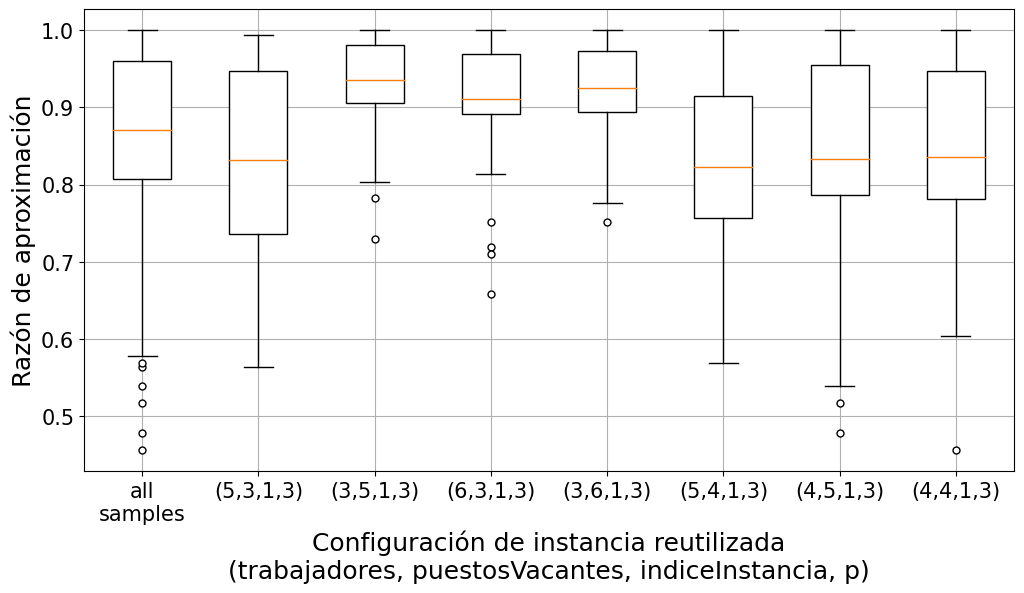

In [11]:
subdatas3 = [approximation_ratios_p3[key].flatten() for key in range(len(keys_p3)) ]
subdatas3.insert(0,approximation_ratios_p3.flatten())
for index,sbd in enumerate(subdatas3):
    subdatas3[index] = [i for i in sbd if i != 0]

means = [np.mean(subdata, axis=0) for subdata in subdatas3]

#'all\nsamples',
plt.figure(figsize=(12, 6))
categories =  ['all\nsamples','(5,3,1,3)','(3,5,1,3)', # RECORDAR QUE LA INSTANCIA REUTILIZADA FUE LA PRIMERA (0 a nivel codigo, notada como 1 para esto)
               '(6,3,1,3)','(3,6,1,3)',
               '(5,4,1,3)','(4,5,1,3)',
               '(4,4,1,3)']

plt.boxplot(subdatas3,labels=categories,usermedians=means,
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=5))#,labels=categories)#,usermedians=means)

if SAVE_IN_ENGLISH:
    xlabe4l = 'parameters reused configuration'
    ylabel = 'Aproximation ratio'
else:
    ylabel = 'Razón de aproximación'
    xlabel = 'Configuración de instancia reutilizada\n(trabajadores, puestosVacantes, indiceInstancia, p)'
plt.xlabel(xlabel)
plt.ylabel(ylabel)

print('instacion por cada categoria (no la total)): ',len(subdatas3[1]))
plt.grid(zorder=100)
plt.show()
# AGREGAR LEGEND QUE DIGA (a,v,i,p),PARA QUE SE NOTE CON LA EXPLICACION DE ARRIBA DE LA TUPLA

### Reusing parameters of p=4 configurations

In [12]:
approximation_ratios_p4 = np.zeros((7, 7, 5))

instances_indexes = range(5)
for file_index,(filename,data) in enumerate(files_p4.items()):
    #approximation_ratios.append([])
    #print(data)
    #print()
    for conf_index,(confname,conf) in enumerate(list(data.items())[1:]):
        #approximation_ratios[file_index].append([])
        for instance_index in instances_indexes:
            if str(instance_index) not in conf.keys():
                continue
            approximation_ratios_p4[file_index,conf_index,instance_index] = conf[str(instance_index)]['approximation ratio']

instacion por cada categoria (no la total)):  34


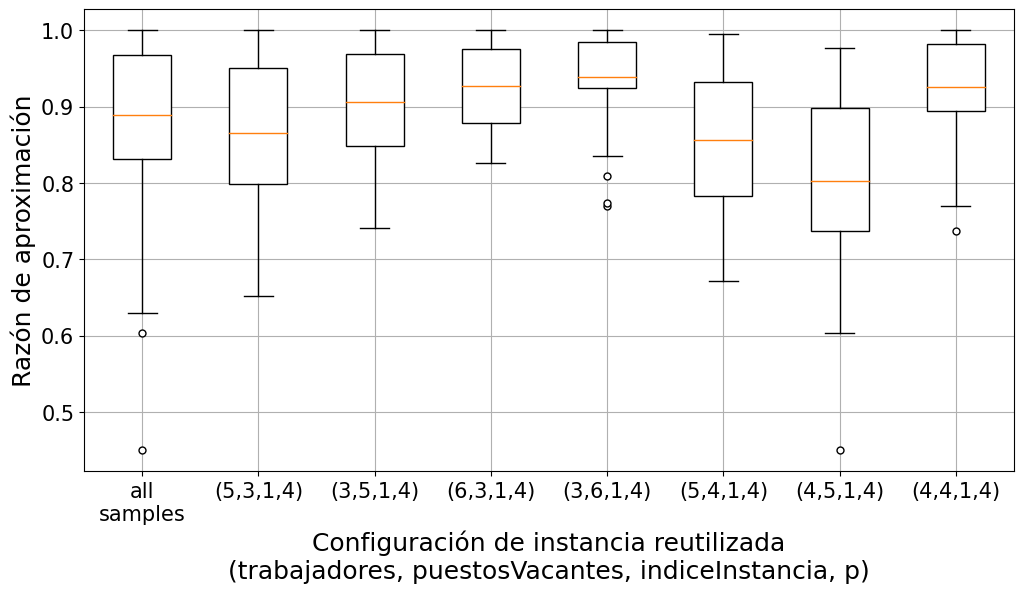

In [13]:
subdatas4 = [approximation_ratios_p4[key].flatten() for key in range(len(keys_p4)) ]
subdatas4.insert(0,approximation_ratios_p4.flatten())
for index,sbd in enumerate(subdatas4):
    subdatas4[index] = [i for i in sbd if i != 0]

means = [np.mean(subdata, axis=0) for subdata in subdatas4]

#'all\nsamples',
plt.figure(figsize=(12, 6))
categories =  ['all\nsamples','(5,3,1,4)','(3,5,1,4)', # RECORDAR QUE LA INSTANCIA REUTILIZADA FUE LA PRIMERA (0 a nivel codigo, notada como 1 para esto)
               '(6,3,1,4)','(3,6,1,4)',
               '(5,4,1,4)','(4,5,1,4)',
               '(4,4,1,4)']

plt.boxplot(subdatas4,labels=categories,usermedians=means,
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=5))#,labels=categories)#,usermedians=means)

if SAVE_IN_ENGLISH:
    xlabel = 'parameters reused configuration'
    ylabel = 'Aproximation ratio'
else:
    ylabel = 'Razón de aproximación'
    xlabel = 'Configuración de instancia reutilizada\n(trabajadores, puestosVacantes, indiceInstancia, p)'
plt.xlabel(xlabel)
plt.ylabel(ylabel)

print('instacion por cada categoria (no la total)): ',len(subdatas4[1]))
plt.grid()
plt.show()
# AGREGAR LEGEND QUE DIGA (a,v,i,p),PARA QUE SE NOTE CON LA EXPLICACION DE ARRIBA DE LA TUPLA

### Reusing parameters of p=5 configurations

In [14]:
approximation_ratios_p5 = np.zeros((7, 7, 5))

instances_indexes = range(5)
for file_index,(filename,data) in enumerate(files_p5.items()):
    #approximation_ratios.append([])
    for conf_index,(confname,conf) in enumerate(list(data.items())[1:]):
        #approximation_ratios[file_index].append([])
        for instance_index in instances_indexes:
            if str(instance_index) not in conf.keys():
                continue
            
            approximation_ratios_p5[file_index,conf_index,instance_index] = conf[str(instance_index)]['approximation ratio']

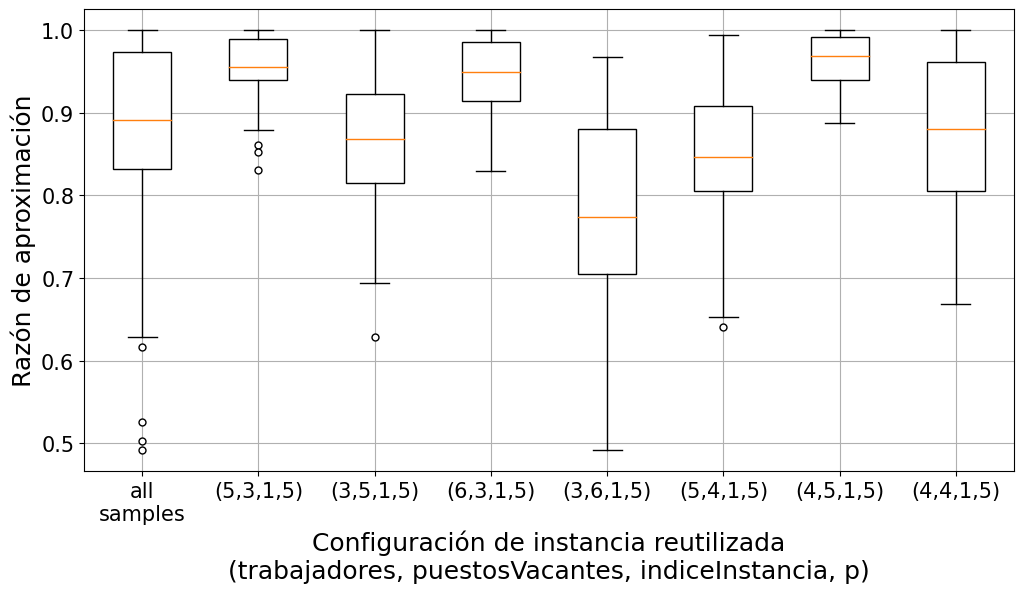

In [15]:
subdatas5 = [approximation_ratios_p5[key].flatten() for key in range(len(keys_p5)) ]
subdatas5.insert(0,approximation_ratios_p5.flatten())
for index,sbd in enumerate(subdatas5):
    subdatas5[index] = [i for i in sbd if i != 0]

means = [np.mean(subdata, axis=0) for subdata in subdatas5]

#'all\nsamples',
plt.figure(figsize=(12, 6))
categories =  ['all\nsamples','(5,3,1,5)','(3,5,1,5)',
               '(6,3,1,5)','(3,6,1,5)',
               '(5,4,1,5)','(4,5,1,5)',
               '(4,4,1,5)']

plt.boxplot(subdatas5,labels=categories,usermedians=means,
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=5))#,labels=categories)#,usermedians=means)

if SAVE_IN_ENGLISH:
    xlabel = 'parameters reused configuration'
    ylabel = 'Aproximation ratio'
else:
    ylabel = 'Razón de aproximación'
    xlabel = 'Configuración de instancia reutilizada\n(trabajadores, puestosVacantes, indiceInstancia, p)'
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.grid()
plt.show()

### Grouped plots

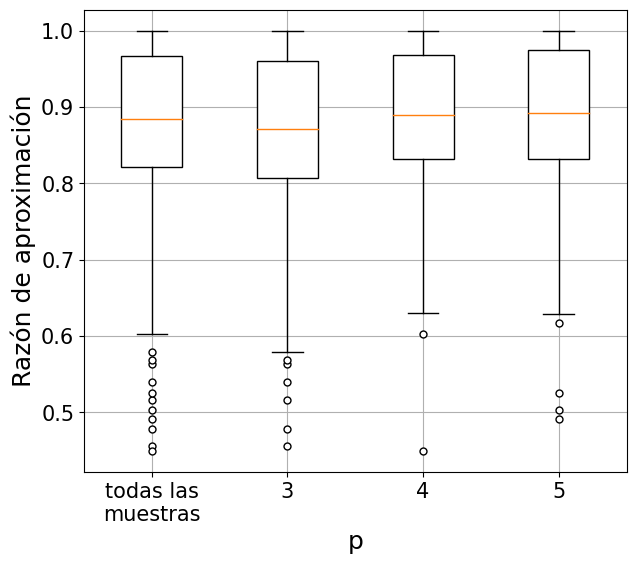

In [17]:
subdatas = [
    subdatas3[0]+subdatas4[0]+subdatas5[0]
    ,subdatas3[0],subdatas4[0],subdatas5[0]]

means = [np.mean(subdata, axis=0) for subdata in subdatas]

plt.figure(figsize=(7, 6))#4))

if SAVE_IN_ENGLISH:
    categories =  ['all samples',3,4,5]
    plt.xlabel('p')
    plt.ylabel('Aproximation ratio')
    save_dir = "results/aproximation_ratio/aproxratio_per_p.pdf"
else:
    categories =  ['todas las\nmuestras',3,4,5]
    plt.xlabel('p')
    plt.ylabel('Razón de aproximación')
    save_dir = "../../../../spanish_imgs/notebooks/results/experiment_reuseOptimizedParameters/aproxratio_per_p.pdf"

boxplot_stats = plt.boxplot(subdatas,labels=categories,usermedians=means
                            ,zorder=2,
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=5))


plt.grid()
plt.savefig(save_dir, bbox_inches='tight')  # Guardar la figura en un archivo
plt.show()

1
3
5


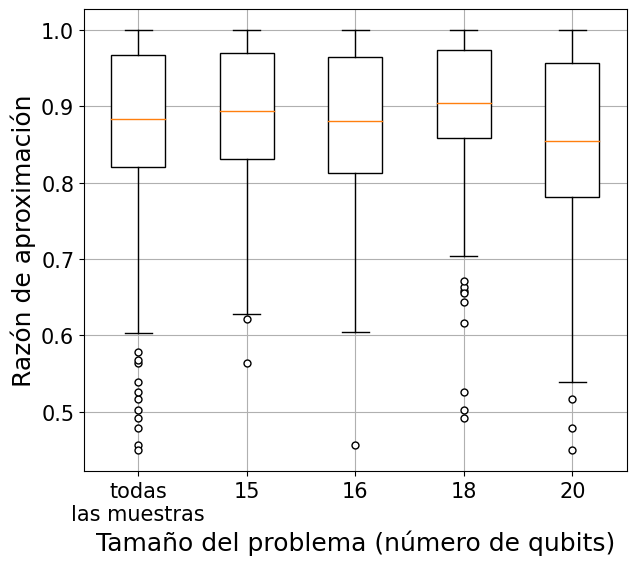

In [117]:
import seaborn as sns

subdatas = [subdatas3[0]+subdatas4[0]+subdatas5[0]]
for i in range(1,7,2):
    print(i)
    subdatas.append(
        subdatas3[i]+subdatas3[i+1]
        +subdatas4[i]+subdatas4[i+1]
        +subdatas5[i]+subdatas5[i+1]
    )
subdatas.insert(2,
    subdatas3[7]
    + subdatas4[7]
    + subdatas5[7]
)
means = [np.mean(subdata, axis=0) for subdata in subdatas]

plt.figure(figsize=(7, 6))#4))

if SAVE_IN_ENGLISH:
    categories =  ['all samples',15,16,18,20]
    plt.xlabel('Problem size (number of qubits)')
    plt.ylabel('Aproximation ratio')
    save_dir = "results/aproximation_ratio/aproxratio_per_problemsize.pdf"
else:
    categories =  ['todas\nlas muestras',15,16,18,20]
    plt.xlabel('Tamaño del problema (número de qubits)')
    plt.ylabel('Razón de aproximación')
    save_dir = "../../../../spanish_imgs/notebooks/results/experiment_reuseOptimizedParameters/aproxratio_per_problemsize.pdf"

boxplot_stats = plt.boxplot(subdatas,labels=categories,usermedians=means
                            ,zorder=2,
            patch_artist=True,
            boxprops=dict(facecolor="white"),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=5))


plt.grid()
plt.savefig(save_dir, bbox_inches='tight')  # Guardar la figura en un archivo
plt.show()